In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [50]:
FP_CO2_45 = '../../../ODAC_data/45_CO2_fingerprints.csv'
FP_H2O_45 = '../../../ODAC_data/45_H2O_fingerprints.csv'

FP_CO2_120 = '../../../ODAC_data/120_CO2_fingerprints.csv'
FP_H2O_120 = '../../../ODAC_data/120_H2O_fingerprints.csv'


def load_data(path):
    return pd.read_csv(path)


In [51]:
# Load and preprocess the data
data = load_data(FP_CO2_45).reset_index().drop(columns=['MOF'])

# Exclude the first row and first column
data = data.iloc[1:, 1:]

# Ensure the data is numeric
data = data.apply(pd.to_numeric, errors='coerce')

# Drop rows with NaN values
data_clean = data.dropna()

# Split features and target variable
X = data_clean.drop(columns=['energy'])
y = data_clean['energy']

# Split the data into training, validation, and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

In [52]:
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=0, keep_empty_features=True)),
    # ('imputer', SimpleImputer(strategy='mean', keep_empty_features=True)),
    ('scaler', StandardScaler()),
    # ('pca', PCA(n_components=20))
])


X_train_pca = pipeline.fit_transform(X_train)
X_valid_pca = pipeline.transform(X_valid)
X_test_pca = pipeline.transform(X_test)

In [53]:
model = Sequential([
    Dense(256, input_dim=X_train_pca.shape[1], activation='relu'),  # Increase number of neurons
    Dropout(0.3),  # Increase dropout rate
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)  # Output layer for regression
])

# Compile the model with a reduced learning rate
model.compile(optimizer=Adam(learning_rate=0.0005), loss='mean_squared_error')  # Adjust learning rate

# Callbacks for early stopping and learning rate reduction
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)  # Increase patience
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=7, min_lr=1e-6)  # Adjust patience and min_lr

# Train the model with increased epochs
history = model.fit(X_train_pca, y_train, validation_data=(X_valid_pca, y_valid), epochs=500, batch_size=32, verbose=1,
                    callbacks=[early_stopping, reduce_lr])

# Evaluate the model on the test set
loss = model.evaluate(X_test_pca, y_test)
print(f'Test loss: {loss}')

# Make predictions
y_pred = model.predict(X_test_pca)

Epoch 1/500


C:\Users\GED\PycharmProjects\Aixelo_Project_DataLab_2025\.venv1\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.1940 - val_loss: 0.6292 - learning_rate: 5.0000e-04
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.1378 - val_loss: 0.6205 - learning_rate: 5.0000e-04
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1304 - val_loss: 0.6295 - learning_rate: 5.0000e-04
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2018 - val_loss: 0.6410 - learning_rate: 5.0000e-04
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.2445 - val_loss: 0.6134 - learning_rate: 5.0000e-04
Epoch 6/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.0670 - val_loss: 0.6355 - learning_rate: 5.0000e-04
Epoch 7/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.5157 - val_loss: 0.6241 - learning_rate: 5.0000e-04
Epoch 8/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.9438 - val_loss: 0.6240 - learning_rate: 5.0000e-04
Epoch 9/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.5732 - val_loss: 0.6199 - learning_rate: 5.0000

Mean Squared Error: 1.2287306988094757
Mean Absolute Error: 0.3618180130095893
R² Score: 0.060532793482422353


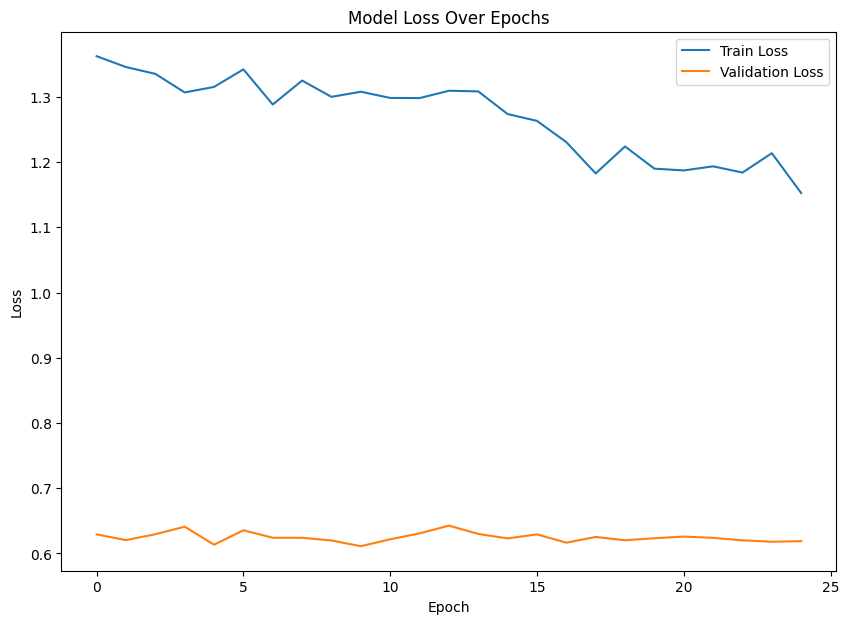

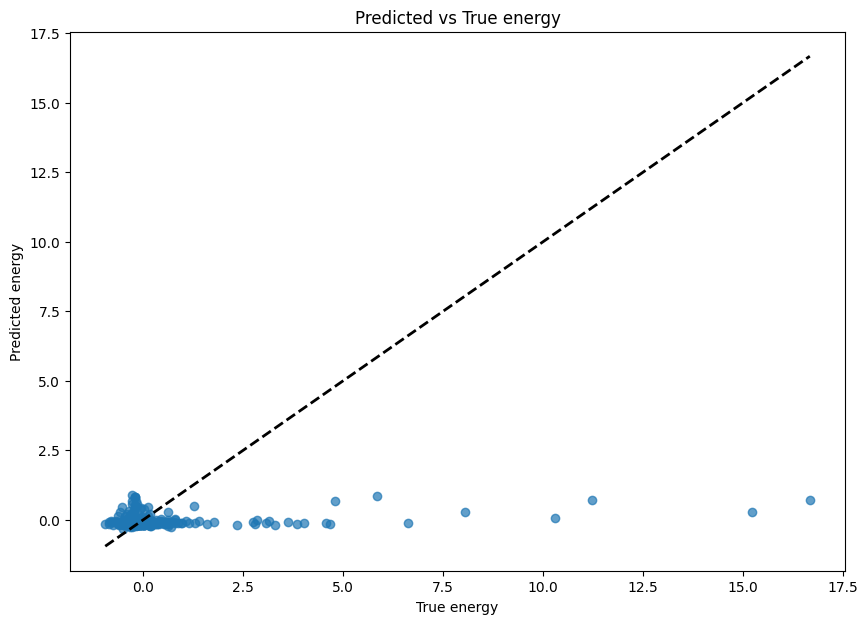

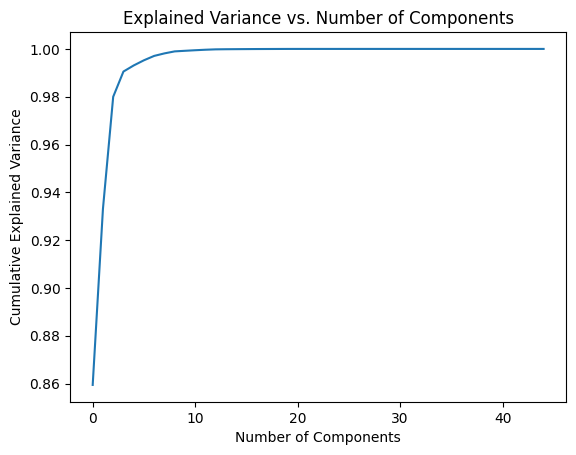

In [54]:
# Calculate regression metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R² Score:", r2)

# Plot the loss over epochs
plt.figure(figsize=(10, 7))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss Over Epochs')
plt.legend()
plt.show()

# Scatter plot of predictions vs true values
plt.figure(figsize=(10, 7))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel('True energy')
plt.ylabel('Predicted energy')
plt.title('Predicted vs True energy')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)  # Line of perfect prediction
plt.show()

# Applying PCA to the full scaled data for the cumulative explained variance plot
pca_full = PCA().fit(X_train)
plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components')
plt.show()
